Libraries

In [25]:
import numpy as np
from scipy.spatial import KDTree
from scipy.interpolate import RegularGridInterpolator
import gymnasium as gym
from gymnasium import spaces

PDE and FD reference Parameters


In [26]:
# ── PDE ────────────────────────────────────────────────────────
alpha = 0.05

# ── FD reference grid ──────────────────────────────────────────
nx    = 10
T     = 0.5
x_fd  = np.linspace(0.0, 1.0, nx)
dx    = x_fd[1] - x_fd[0]

dt_cfl = 0.45 * dx**2 / alpha
nt     = max(int(np.ceil(T / dt_cfl)) + 1, 10)
t_fd   = np.linspace(0.0, T, nt)
dt     = t_fd[1] - t_fd[0]

Analytical diffusion solution


In [27]:
def u_true(x, t):
    return np.sin(np.pi * x) * np.exp(-alpha * np.pi**2 * t)

FD For diffusion

In [28]:
def build_fd_reference():
    u = np.zeros((nx, nt))
    u[:, 0] = u_true(x_fd, 0.0)

    r_diff = alpha * dt / dx**2

    for it in range(nt - 1):
        un = u[:, it]
        u[1:-1, it+1] = (un[1:-1]
                         + r_diff * (un[2:] - 2*un[1:-1] + un[:-2]))
        u[0,   it+1] = 0.0
        u[-1,  it+1] = 0.0

    interp = RegularGridInterpolator(
        (x_fd, t_fd), u, method='linear',
        bounds_error=False, fill_value=None
    )
    return u, interp

__init__

In [29]:
class VisitedSet:

    def __init__(self, rebuild_every=200):
        self._pts           = []
        self._norm          = []
        self._tree          = None
        self._dirty         = 0
        self._rebuild_every = rebuild_every

    def add(self, x, t, u):
        self._pts.append((x, t, u))
        self._norm.append((x / dx, t / dt))
        self._dirty += 1
        if self._dirty >= self._rebuild_every:
            self._rebuild()

    def _rebuild(self):
        self._tree  = KDTree(np.array(self._norm))
        self._dirty = 0

    def _ensure(self):
        if self._tree is None:
            self._rebuild()

    def find_neighbours(self, x_star, t_star, n_neighbours=5):
        self._ensure()
        xn  = x_star / dx
        tn  = t_star / dt
        bn  = 2.0
        while True:
            idxs = self._tree.query_ball_point([xn, tn], r=bn, p=np.inf)
            nb   = [
                self._pts[i] for i in idxs
                if 0 < (t_star - self._pts[i][1]) <= bn * dt
            ]
            if len(nb) >= n_neighbours:
                nb.sort(key=lambda p: (p[0]-x_star)**2 + (p[1]-t_star)**2)
                return nb[:n_neighbours]
            bn = min(bn * 1.5, 15.0)
            if bn >= 15.0:
                return None

    def __len__(self):
        return len(self._pts)

GFDM Solver


In [30]:
def solve_weights(dx_i, dt_i):
    """
    Pure diffusion constraint matrix.
    Returns (w, success).
    """
    h   = max(np.max(np.abs(dx_i)), 1e-12)

    A = np.array([
        np.ones(len(dx_i)),
        dx_i / h,
        (0.5 * dx_i**2 + alpha * dt_i) / h**2,
    ])
    b = np.array([1.0, 0.0, 0.0])

    cond = np.linalg.cond(A)
    if cond > 1e4:
        return None, False

    w = np.linalg.lstsq(A, b, rcond=None)[0]

    if np.max(np.abs(w)) > 3.0 / len(dx_i):
        return None, False
    if np.min(w) < -1.0:
        return None, False

    return w, True

PDEEnvironment

In [ ]:
class PDEEnvironment(gym.Env):

#-----------------------------------first part-----------------------------------------
    def __init__(self):
        super().__init__()

        # ── PDE constants────────────────────────────────────────────────────────
        self.alpha = alpha

        # ── Grid variables───────────────────────────────────────────────────────
        self.nx   = nx
        self.nt   = nt
        self.x_fd = x_fd
        self.t_fd = t_fd
        self.dx   = dx
        self.dt   = dt
        self.T    = T

        # ── Target point (z*) ─────────────────────────────────────────────────────
        self.x_star = 0.5
        self.t_star = 3 * dt        # CHANGED: was 5 * dt

        # ── RL parameters ──────────────────────────────────────────────────────────
        self.N      = 5
        self.K_max  = 20            # CHANGED: was 1000
        self.lam    = 0.001
        self.Kx     = 1
        self.Kt     = 1

        # ── GFDM how many neighbours───────────────────────────────────────────────
        self.n_neighbours = 5

        # ── Termination tolerance ──────────────────────────────────────
        self.eps_x = 0.5 * dx
        self.eps_t = 0.5 * dt

        # ── Walker initial positions ────────────────────────────────────────────
        self.walker_init_x = [0.3, 0.4, 0.5, 0.6, 0.7]

        # ── FD reference built once ────────────────────────────────────
        _, self.fd_interp = build_fd_reference()

        # ── Episode state (reset() fills these) ───────────────────────
        self.visited    = None
        self.walker_x   = None
        self.walker_t   = None
        self.walker_u   = None
        self.step_count = 0

        # ── Gym spaces ─────────────────────────────────────────────────   ADDED
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(3 * self.N + 2,), dtype=np.float32
        )
        self.action_space = spaces.MultiDiscrete([6] * self.N)


#--------------------------------------------------------------------------------
#second part
    def reset(self, seed=None, options=None):   # CHANGED: added seed/options for gym compat
        super().reset(seed=seed)

        # ── Fresh visited list ──────────────────────────────────────────────────
        self.visited = VisitedSet()

        # ── Seed with IC ────────────────────────────────────────────────────────
        for ix in range(self.nx):
            x = self.x_fd[ix]
            self.visited.add(x, 0.0, u_true(x, 0.0))

        # ── Seed with BCs ──────────────────────────────────────────────
        for it in range(1, self.nt):
            self.visited.add(0.0, self.t_fd[it], 0.0)
            self.visited.add(1.0, self.t_fd[it], 0.0)

        # ── Place walkers at t=0 ───────────────────────────────────────
        self.walker_x = np.array(self.walker_init_x, dtype=float)
        self.walker_t = np.zeros(self.N)
        self.walker_u = np.array([u_true(x, 0.0) for x in self.walker_init_x])

        # ── Reset step counter ─────────────────────────────────────────
        self.step_count = 0

        return self._build_state(), {}   # CHANGED: gym requires (obs, info)

    def _build_state(self):
        state = []
        for i in range(self.N):
            state.append(self.walker_x[i])
            state.append(self.walker_t[i])
            state.append(self.walker_u[i])
        state.append(self.x_star)
        state.append(self.t_star)
        return np.array(state, dtype=np.float32)   # CHANGED: float32 to match obs space

    def _decode_action(self, action_idx):
        # dx ∈ {-1, 0, +1} · Δx  → 3 options
        # dt ∈ {0, 1}      · Δt  → 2 options
        # layout: action_idx = dx_idx * 2 + dt_idx
        # NOTE: action 2 (dx=0, dt=0) is always rejected — effectively a no-op

        dx_idx = action_idx // 2    # CHANGED: was // 5
        dt_idx = action_idx % 2     # CHANGED: was % 5

        dx = (dx_idx - self.Kx) * self.dx
        dt = dt_idx * self.dt

        return dx, dt

    def _check_collision(self, x, t):
        for (xv, tv, _) in self.visited._pts:
            if abs(xv - x) < self.eps_x and abs(tv - t) < self.eps_t:
                return True
        return False

    def _gfdm_solve(self, x_star, t_star):

        nb = self.visited.find_neighbours(x_star, t_star, self.n_neighbours)
        if nb is None:
            return None, False

        nb    = np.array(nb)
        dx_i  = nb[:, 0] - x_star
        dt_i  = nb[:, 1] - t_star

        if not (np.min(dx_i) < 0 < np.max(dx_i)):
            return None, False

        w, success = solve_weights(dx_i, dt_i)
        if not success:
            return None, False

        u_hat = float(w @ nb[:, 2])

        return u_hat, True

    def step(self, actions):

        self.step_count += 1
        done    = False
        reward  = 0.0
        info    = {'accepted': [], 'rejected': [], 'reached': False}

        for i in range(self.N):

            dx, dt = self._decode_action(actions[i])

            x_new = self.walker_x[i] + dx
            t_new = self.walker_t[i] + dt

            if not (0.0 <= x_new <= 1.0 and 0.0 < t_new <= self.T):
                info['rejected'].append((i, 'bounds'))
                continue

            if self._check_collision(x_new, t_new):
                info['rejected'].append((i, 'collision'))
                continue

            u_hat, success = self._gfdm_solve(x_new, t_new)
            if not success:
                info['rejected'].append((i, 'gfdm'))
                continue

            self.visited.add(x_new, t_new, u_hat)
            self.walker_x[i] = x_new
            self.walker_t[i] = t_new
            self.walker_u[i] = u_hat
            info['accepted'].append(i)

            if (abs(x_new - self.x_star) < self.eps_x and
                abs(t_new - self.t_star) < self.eps_t):
                done = True
                info['reached'] = True

        if done:
            u_pred         = self._gfdm_solve(self.x_star, self.t_star)[0]
            u_ref          = u_true(self.x_star, self.t_star)
            reward         = -abs(u_pred - u_ref) - self.lam * self.step_count
            info['u_pred'] = u_pred
            info['u_ref']  = u_ref
            info['error']  = abs(u_pred - u_ref)

        elif self.step_count >= self.K_max:
            done   = True
            reward = -1.0
            info['timeout'] = True

        state = self._build_state()
        return state, reward, done, False, info   

In [32]:
env   = PDEEnvironment()
state = env.reset()

trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}

done           = False
total_accepted = 0
total_rejected = {}

while not done:
    actions = [np.random.randint(6) for _ in range(env.N)]
    state, reward, done, _, info = env.step(actions)


    total_accepted += len(info['accepted'])
    for (_, reason) in info['rejected']:
        total_rejected[reason] = total_rejected.get(reason, 0) + 1

    for i in info['accepted']:
        trajectories[i].append((env.walker_x[i], env.walker_t[i]))

visited_log = [(x, t) for (x, t, _) in env.visited._pts]

print(f"Steps:          {env.step_count}")
print(f"Reward:         {reward:.6f}")
print(f"Reached:        {info.get('reached', False)}")
print(f"Timeout:        {info.get('timeout', False)}")
print(f"Total accepted: {total_accepted}")
print(f"Rejections:     {total_rejected}")
print(f"Walker t positions: {env.walker_t}")

Steps:          3
Reward:         -0.003953
Reached:        True
Timeout:        False
Total accepted: 5
Rejections:     {'bounds': 7, 'collision': 3}
Walker t positions: [0.         0.11111111 0.         0.16666667 0.        ]


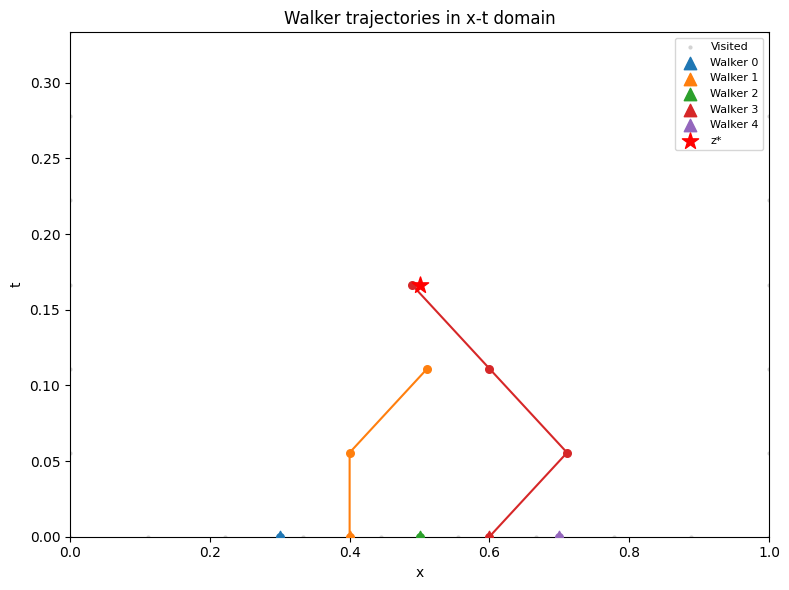

In [33]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(8, 6))

vx = [p[0] for p in visited_log]
vt = [p[1] for p in visited_log]
ax.scatter(vx, vt, s=4, color='lightgray', zorder=1, label='Visited')

colors = cm.tab10.colors
for i, traj in trajectories.items():
    xs = [p[0] for p in traj]
    ts = [p[1] for p in traj]
    ax.plot(xs, ts, '-', color=colors[i], linewidth=1.5, zorder=2)
    ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
    ax.scatter(xs[0], ts[0], s=80, color=colors[i],
               marker='^', zorder=4, label=f'Walker {i}')

ax.scatter(env.x_star, env.t_star, s=150, color='red',
           marker='*', zorder=5, label='z*')

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Walker trajectories in x-t domain')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, env.t_star * 2)
plt.tight_layout()
plt.show()

In [34]:
env.reset()
for step in range(3):
    actions = [3] * env.N      # all walkers go straight up
    state, reward, done, _, info = env.step(actions)
    print(f"step {step+1} | done={done} | reached={info.get('reached')} | reward={reward:.6f}")

step 1 | done=False | reached=False | reward=0.000000
step 2 | done=False | reached=False | reward=0.000000
step 3 | done=True | reached=True | reward=-0.003953


In [35]:
from stable_baselines3 import PPO

model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=500_000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 10.4     |
|    ep_rew_mean     | -0.217   |
| time/              |          |
|    fps             | 220      |
|    iterations      | 1        |
|    time_elapsed    | 9        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 10.9        |
|    ep_rew_mean          | -0.296      |
| time/                   |             |
|    fps                  | 178         |
|    iterations           | 2           |
|    time_elapsed         | 22          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008800057 |
|    clip_fraction        | 0.107       |
|    clip_range           | 0.2         |
|    entropy_loss   

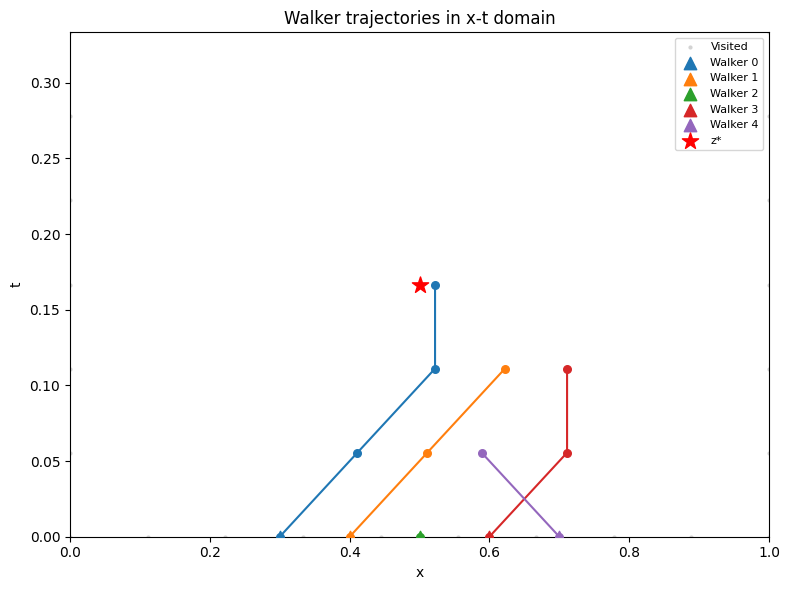

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
obs, _ = env.reset()
trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, info = env.step(action)
    for i in info['accepted']:
        trajectories[i].append((env.walker_x[i], env.walker_t[i]))

visited_log = [(x, t) for (x, t, _) in env.visited._pts]
fig, ax = plt.subplots(figsize=(8, 6))

vx = [p[0] for p in visited_log]
vt = [p[1] for p in visited_log]
ax.scatter(vx, vt, s=4, color='lightgray', zorder=1, label='Visited')

colors = cm.tab10.colors
for i, traj in trajectories.items():
    xs = [p[0] for p in traj]
    ts = [p[1] for p in traj]
    ax.plot(xs, ts, '-', color=colors[i], linewidth=1.5, zorder=2)
    ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
    ax.scatter(xs[0], ts[0], s=80, color=colors[i],
               marker='^', zorder=4, label=f'Walker {i}')

ax.scatter(env.x_star, env.t_star, s=150, color='red',
           marker='*', zorder=5, label='z*')

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Walker trajectories in x-t domain')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, env.t_star * 2)
plt.tight_layout()
plt.show()